In [1]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 3.9 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 4.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.9 MB 4.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 4.3 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 4.2 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 4.3 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 4.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 4.2 MB/s  0:00:02

   ------------------

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv(r"C:\Users\Kirti\Downloads\Nassau Candy Distributor.csv")

In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [9]:
df['Units'] = df['Units'].fillna(df['Units'].median())

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')

df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [12]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [13]:
df = df[df['Sales'] > 0]
df = df[df['Gross Profit'] > 0]

In [14]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

In [15]:
df['Profit Per Unit'] = df['Gross Profit'] / df['Units']

In [16]:
total_sales = df['Sales'].sum()

df['Revenue Contribution'] = (df['Sales'] / total_sales) * 100

In [17]:
total_profit = df['Gross Profit'].sum()

df['Profit Contribution'] = (df['Gross Profit'] / total_profit) * 100

In [18]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Gross Margin %',
       'Profit Per Unit', 'Revenue Contribution', 'Profit Contribution'],
      dtype='object')

In [19]:
top_products = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64


In [20]:
margin_products = df.groupby('Product Name')['Gross Margin %'].mean().sort_values(ascending=False)

print(margin_products.head(10))

Product Name
Everlasting Gobstopper               80.000000
Hair Toffee                          77.777778
Wonka Bar - Nutty Crunch Surprise    71.346705
Wonka Bar -Scrumdiddlyumptious       69.444444
Wonka Bar - Fudge Mallows            66.666667
Wonka Bar - Triple Dazzle Caramel    65.333333
Wonka Bar - Milk Chocolate           64.923077
Laffy Taffy                          62.311558
Fizzy Lifting Drinks                 60.000000
Wonka Gum                            52.000000
Name: Gross Margin %, dtype: float64


In [21]:
division_analysis = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean'
}).reset_index()

print(division_analysis)

    Division      Sales  Gross Profit  Gross Margin %
0  Chocolate  131692.90      88824.62       67.458162
1      Other    9663.25       4333.45       37.672457
2      Sugar     427.48        284.73       57.689001


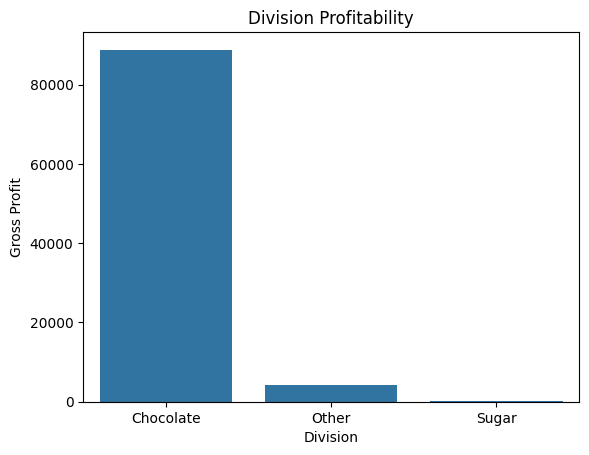

In [22]:
sns.barplot(x='Division', y='Gross Profit', data=division_analysis)
plt.title("Division Profitability")
plt.show()

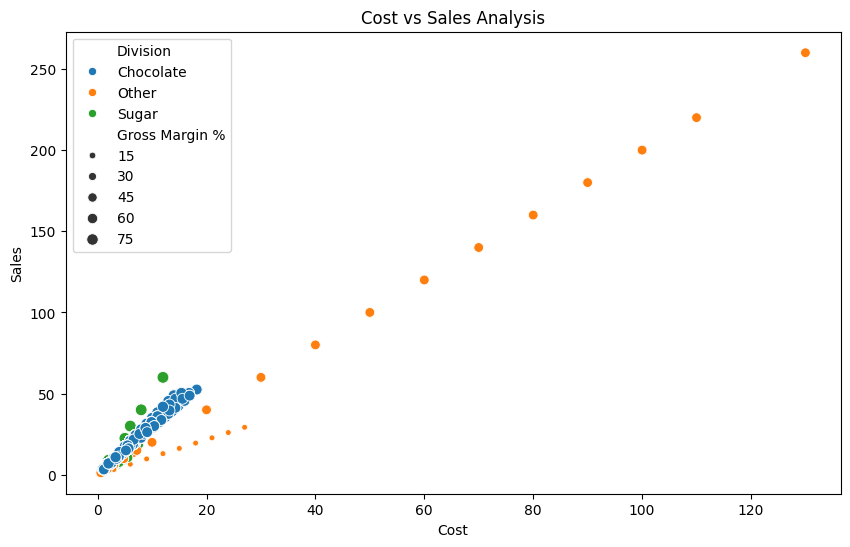

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Cost',
    y='Sales',
    hue='Division',
    size='Gross Margin %',
    data=df
)

plt.title("Cost vs Sales Analysis")
plt.show()

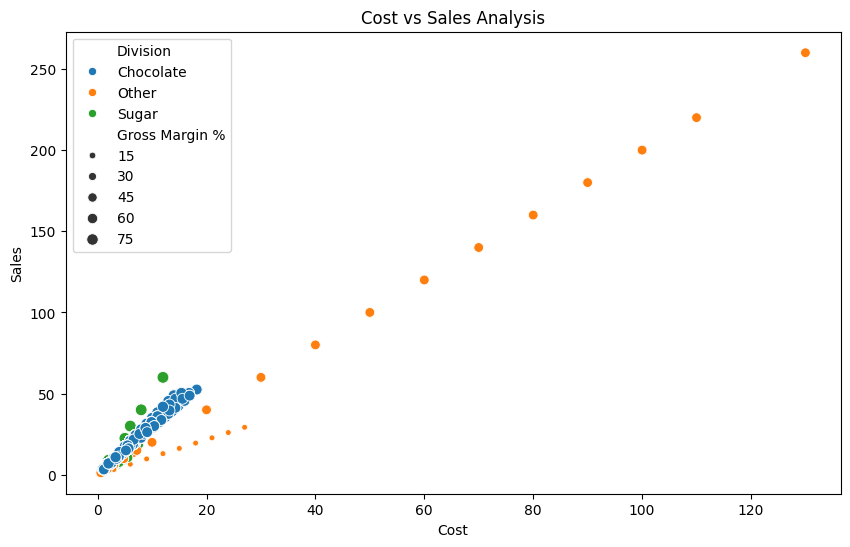

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Cost',
    y='Sales',
    hue='Division',
    size='Gross Margin %',
    data=df
)

plt.title("Cost vs Sales Analysis")
plt.show()

In [25]:
profit_df = df.groupby('Product Name')['Gross Profit'].sum().reset_index()

profit_df = profit_df.sort_values(by='Gross Profit', ascending=False)

profit_df['Cumulative Profit %'] = (
    profit_df['Gross Profit'].cumsum() /
    profit_df['Gross Profit'].sum()
) * 100

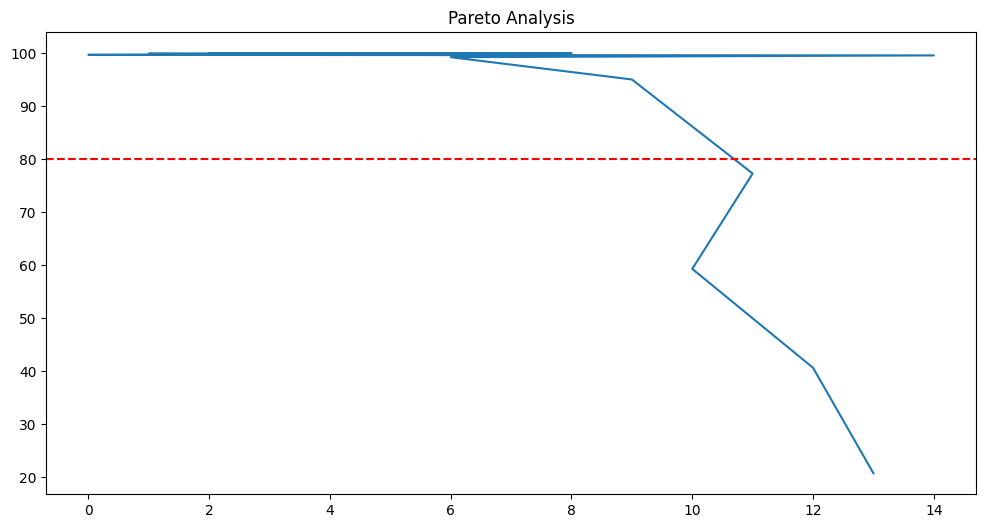

In [26]:
plt.figure(figsize=(12,6))

plt.plot(profit_df['Cumulative Profit %'])

plt.axhline(80, color='red', linestyle='--')

plt.title("Pareto Analysis")
plt.show()

In [27]:
def risk_flag(margin):
    if margin < 10:
        return "High Risk"
    elif margin < 20:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Margin Risk'] = df['Gross Margin %'].apply(risk_flag)

In [28]:
top_products = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

print(top_products.head(10))

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64


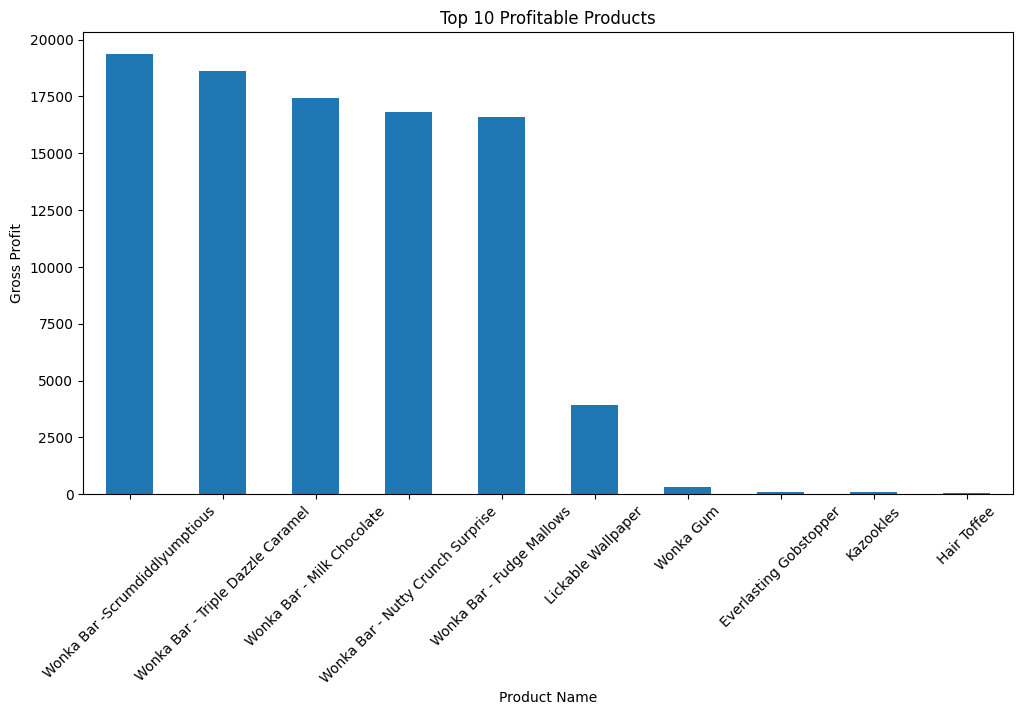

In [29]:
plt.figure(figsize=(12,6))

top_products.head(10).plot(kind='bar')

plt.title("Top 10 Profitable Products")
plt.ylabel("Gross Profit")
plt.xticks(rotation=45)

plt.show()

In [30]:
division_analysis = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean'
}).reset_index()

print(division_analysis)

    Division      Sales  Gross Profit  Gross Margin %
0  Chocolate  131692.90      88824.62       67.458162
1      Other    9663.25       4333.45       37.672457
2      Sugar     427.48        284.73       57.689001


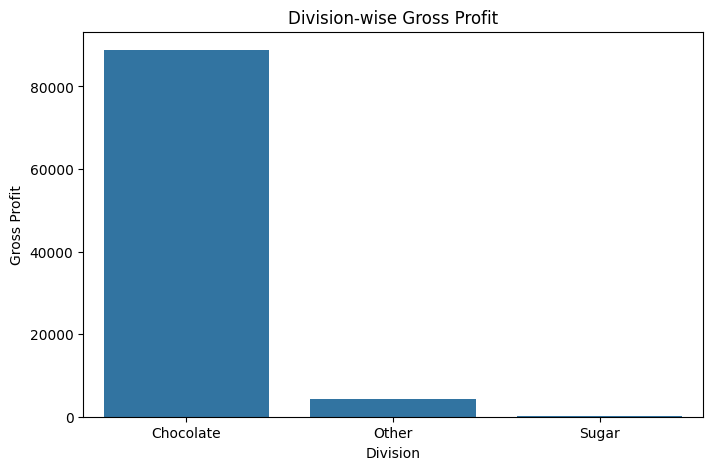

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Division',
    y='Gross Profit',
    data=division_analysis
)

plt.title("Division-wise Gross Profit")

plt.show()

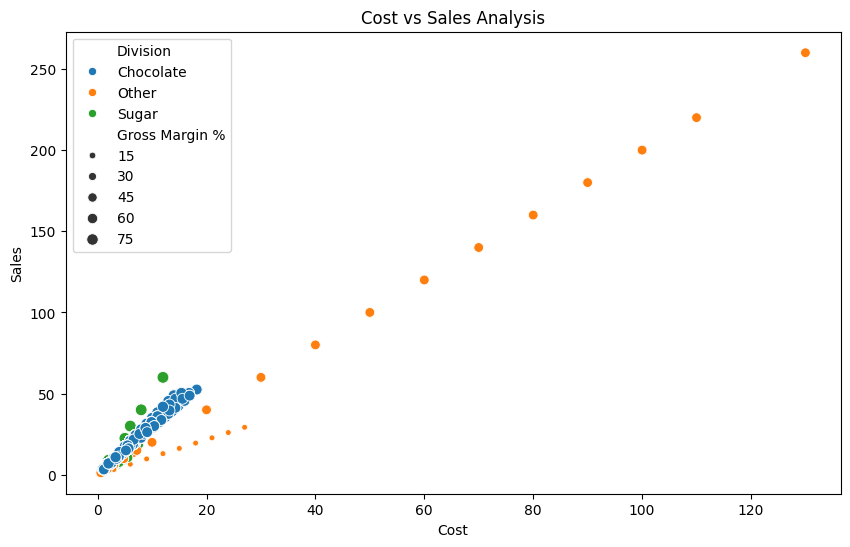

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Cost',
    y='Sales',
    hue='Division',
    size='Gross Margin %',
    data=df
)

plt.title("Cost vs Sales Analysis")

plt.show()